🎵 Sampling Methods Comparison Tutorial
✅ Generated signals with frequency: 10 Hz
✅ Signal duration: 2.0 seconds
✅ Original sampling rate: 1000 Hz
✅ Uniform sampling completed for rates: [20, 40, 80] Hz
✅ Random sampling completed for average rates: [20, 40, 80] Hz
✅ Adaptive sampling completed for thresholds: [0.05, 0.1, 0.2]

📊 Plotting Sampling Comparison...


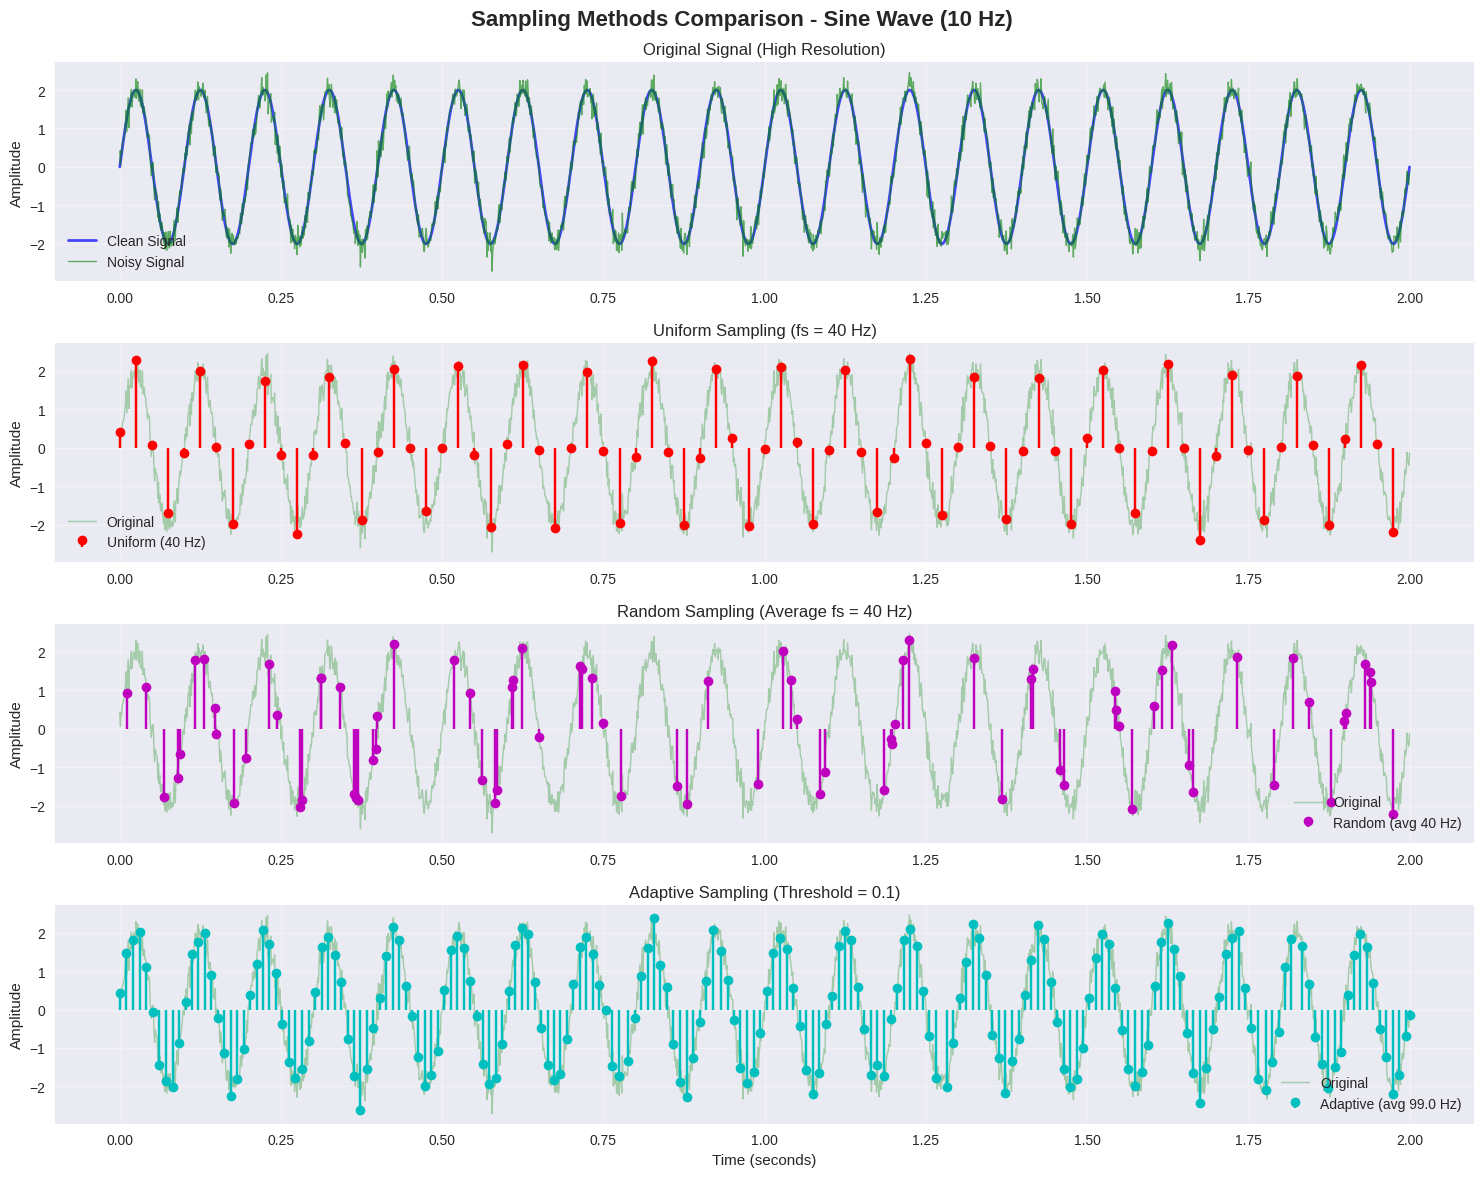


📈 SAMPLING STATISTICS

🔸 SINE WAVE ANALYSIS:
----------------------------------------
Uniform Sampling   :  80 samples ( 40.0 Hz)
Random Sampling    :  80 samples ( 40.0 Hz)
Adaptive Sampling  : 198 samples ( 99.0 Hz)
Reconstruction MSE:
  Uniform  : 0.1394
  Random   : 1.3658
  Adaptive : 0.0242

🔸 SQUARE WAVE ANALYSIS:
----------------------------------------
Uniform Sampling   :  80 samples ( 40.0 Hz)
Random Sampling    :  80 samples ( 40.0 Hz)
Adaptive Sampling  : 185 samples ( 92.5 Hz)
Reconstruction MSE:
  Uniform  : 1.3483
  Random   : 3.1239
  Adaptive : 0.5735

🔊 Frequency Domain Analysis...


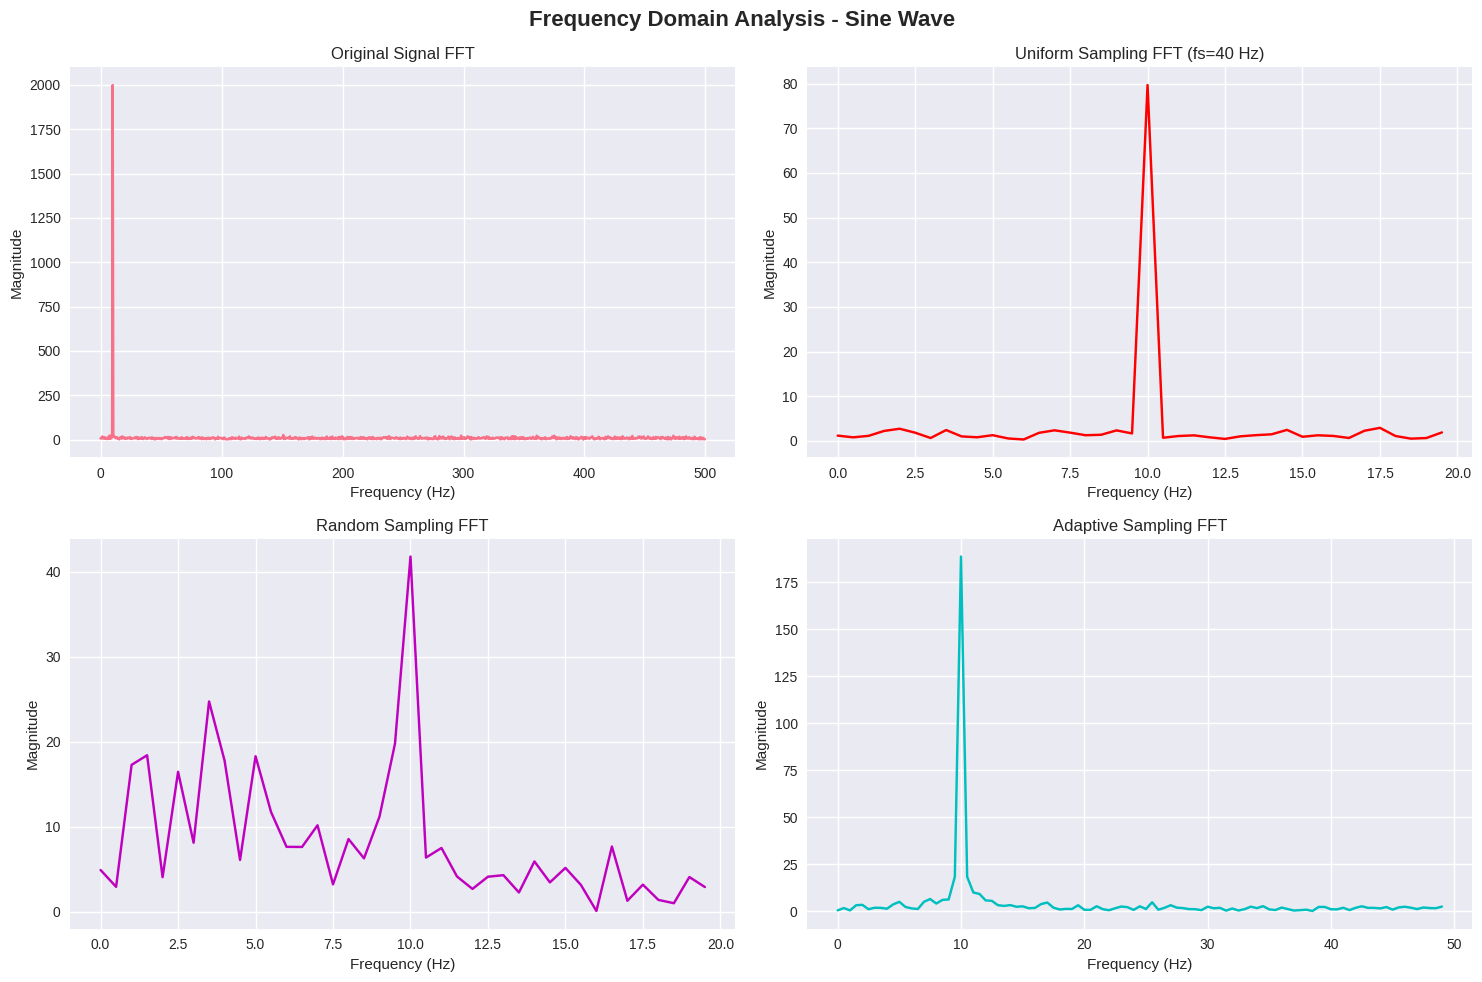


🎯 SAMPLING METHODS SUMMARY

🔸 UNIFORM SAMPLING:
   Advantages: Simple, predictable, easy reconstruction
   Disadvantages: Aliasing issues, fixed data rate
   Use Cases: Digital audio, regular monitoring

🔸 RANDOM SAMPLING:
   Advantages: Reduces aliasing, good for compressed sensing
   Disadvantages: Complex reconstruction, irregular spacing
   Use Cases: Compressed sensing, statistical analysis

🔸 ADAPTIVE SAMPLING:
   Advantages: Efficient, preserves signal features
   Disadvantages: Complex algorithm, variable data rate
   Use Cases: Real-time systems, sensor networks

✅ Tutorial completed successfully!
📝 Key takeaways:
   • Uniform sampling: Best for regular signals, fs ≥ 2×fmax (Nyquist)
   • Random sampling: Good for avoiding aliasing, complex reconstruction
   • Adaptive sampling: Most efficient for varying signals

🔧 Parameter Exploration Functions Available:
   • plot_sampling_comparison(signal_type, sampling_rate, threshold)
   • plot_frequency_analysis(signal_type, sampling

ValueError: 'blue-' is not a valid format string (unrecognized character 'l')

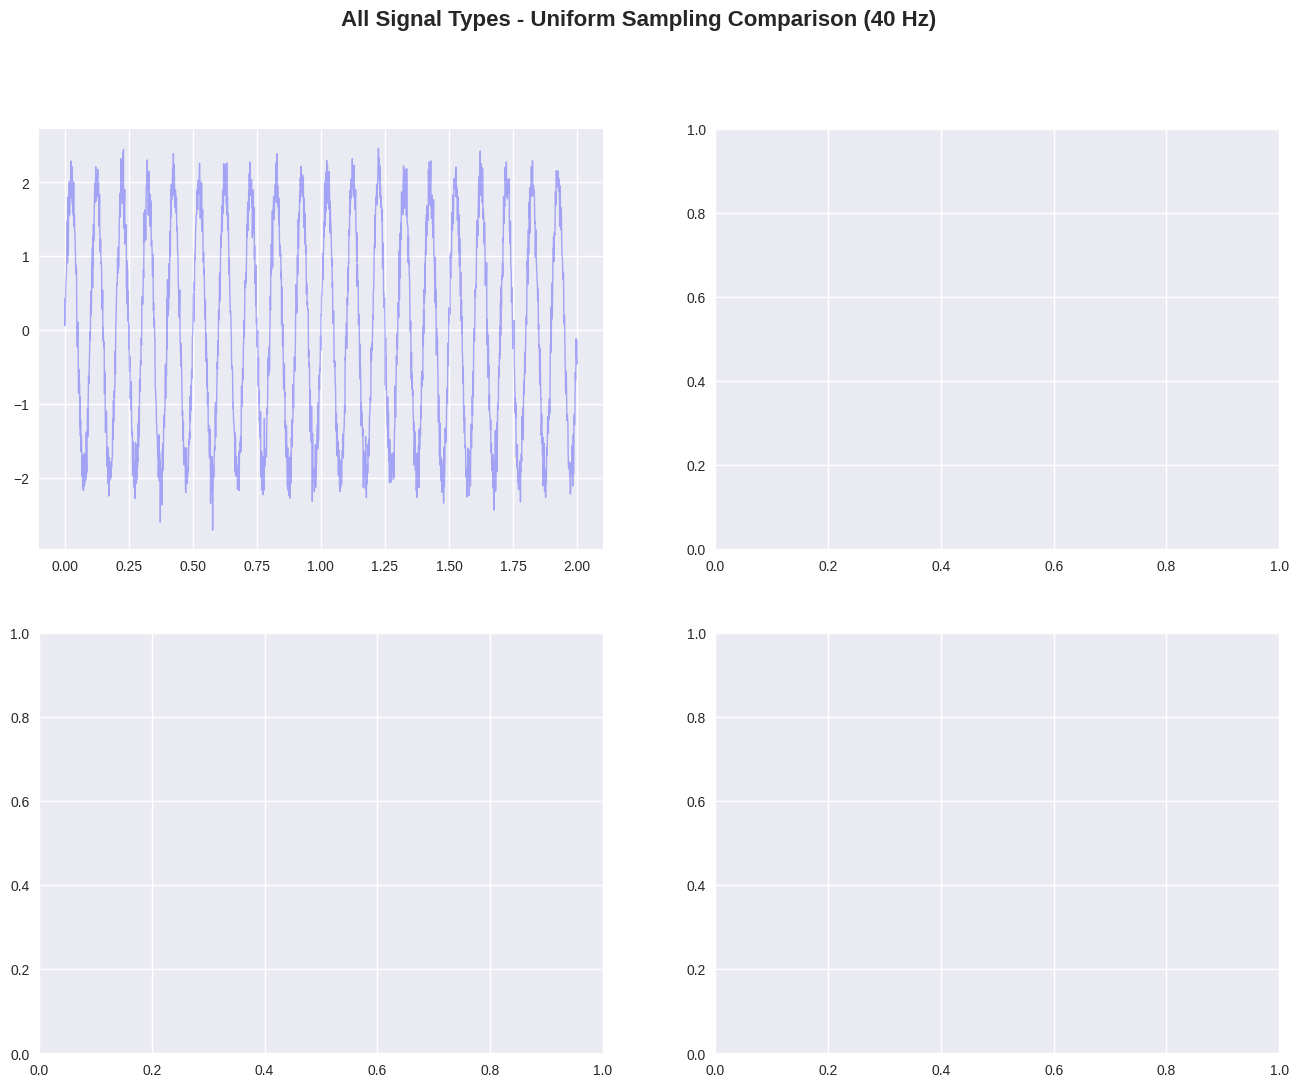

In [1]:
# Sampling Methods Comparison in Python
# Author: Digital Signal Processing Tutorial
# Date: June 2025

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random
from matplotlib.patches import Rectangle
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("🎵 Sampling Methods Comparison Tutorial")
print("=" * 50)

# =============================================================================
# 1. SIGNAL GENERATION
# =============================================================================

def generate_signal(t, freq=5, amplitude=1, signal_type='sine', noise_level=0.1):
    """
    Generate different types of signals with optional noise

    Parameters:
    - t: time array
    - freq: frequency in Hz
    - amplitude: signal amplitude
    - signal_type: 'sine', 'cosine', 'square', 'sawtooth', 'composite'
    - noise_level: noise amplitude
    """
    omega = 2 * np.pi * freq

    if signal_type == 'sine':
        signal_clean = amplitude * np.sin(omega * t)
    elif signal_type == 'cosine':
        signal_clean = amplitude * np.cos(omega * t)
    elif signal_type == 'square':
        signal_clean = amplitude * signal.square(omega * t)
    elif signal_type == 'sawtooth':
        signal_clean = amplitude * signal.sawtooth(omega * t)
    elif signal_type == 'composite':
        # Composite signal with multiple frequencies
        signal_clean = (amplitude * np.sin(omega * t) +
                       0.5 * amplitude * np.sin(3 * omega * t) +
                       0.3 * amplitude * np.sin(5 * omega * t))
    else:
        signal_clean = amplitude * np.sin(omega * t)

    # Add noise
    noise = noise_level * np.random.randn(len(t))
    signal_noisy = signal_clean + noise

    return signal_noisy, signal_clean

# Generate time axis and signals
duration = 2.0  # seconds
fs_original = 1000  # High sampling rate for "continuous" signal
t_continuous = np.linspace(0, duration, int(fs_original * duration))

# Generate different types of signals
freq_signal = 10  # Hz
amplitude = 2
noise_level = 0.2

signals = {}
signal_types = ['sine', 'square', 'sawtooth', 'composite']

for sig_type in signal_types:
    noisy, clean = generate_signal(t_continuous, freq_signal, amplitude, sig_type, noise_level)
    signals[sig_type] = {'noisy': noisy, 'clean': clean}

print(f"✅ Generated signals with frequency: {freq_signal} Hz")
print(f"✅ Signal duration: {duration} seconds")
print(f"✅ Original sampling rate: {fs_original} Hz")

# =============================================================================
# 2. SAMPLING METHOD 1: UNIFORM SAMPLING
# =============================================================================

def uniform_sampling(signal, t_original, sampling_rate):
    """
    Uniform (Regular) Sampling
    """
    # Calculate sampling interval
    dt_sample = 1 / sampling_rate

    # Generate uniform sampling times
    t_samples = np.arange(0, duration, dt_sample)

    # Interpolate signal at sampling times
    samples = np.interp(t_samples, t_original, signal)

    return samples, t_samples

# Apply uniform sampling with different rates
uniform_results = {}
sampling_rates = [20, 40, 80]  # Hz

for fs in sampling_rates:
    uniform_results[fs] = {}
    for sig_type in signal_types:
        samples, t_samples = uniform_sampling(signals[sig_type]['noisy'],
                                            t_continuous, fs)
        uniform_results[fs][sig_type] = {'samples': samples, 'times': t_samples}

print(f"✅ Uniform sampling completed for rates: {sampling_rates} Hz")

# =============================================================================
# 3. SAMPLING METHOD 2: RANDOM SAMPLING
# =============================================================================

def random_sampling(signal, t_original, avg_sampling_rate, seed=42):
    """
    Random (Non-uniform) Sampling
    """
    np.random.seed(seed)  # For reproducible results

    # Calculate expected number of samples
    total_samples = int(avg_sampling_rate * duration)

    # Generate random sampling times
    t_samples = np.sort(np.random.uniform(0, duration, total_samples))

    # Interpolate signal at random sampling times
    samples = np.interp(t_samples, t_original, signal)

    return samples, t_samples

# Apply random sampling
random_results = {}

for fs in sampling_rates:
    random_results[fs] = {}
    for sig_type in signal_types:
        samples, t_samples = random_sampling(signals[sig_type]['noisy'],
                                           t_continuous, fs)
        random_results[fs][sig_type] = {'samples': samples, 'times': t_samples}

print(f"✅ Random sampling completed for average rates: {sampling_rates} Hz")

# =============================================================================
# 4. SAMPLING METHOD 3: ADAPTIVE SAMPLING
# =============================================================================

def adaptive_sampling(signal, t_original, threshold_factor=0.1, min_interval=0.01, max_interval=0.1):
    """
    Adaptive Sampling based on signal derivative
    """
    samples = [signal[0]]
    t_samples = [t_original[0]]

    i = 0
    while i < len(signal) - 1:
        current_sample = signal[i]
        current_time = t_original[i]

        # Look ahead to find next sampling point
        j = i + 1
        max_j = min(i + int(max_interval * fs_original), len(signal) - 1)
        min_j = min(i + int(min_interval * fs_original), len(signal) - 1)

        # Calculate threshold based on signal amplitude
        threshold = threshold_factor * np.std(signal)

        # Find next point where change exceeds threshold or max interval reached
        while j < max_j:
            if abs(signal[j] - current_sample) > threshold and j >= min_j:
                break
            j += 1

        # Add sample
        samples.append(signal[j])
        t_samples.append(t_original[j])
        i = j

    return np.array(samples), np.array(t_samples)

# Apply adaptive sampling
adaptive_results = {}
threshold_factors = [0.05, 0.1, 0.2]

for threshold in threshold_factors:
    adaptive_results[threshold] = {}
    for sig_type in signal_types:
        samples, t_samples = adaptive_sampling(signals[sig_type]['noisy'],
                                             t_continuous, threshold)
        adaptive_results[threshold][sig_type] = {'samples': samples, 'times': t_samples}

print(f"✅ Adaptive sampling completed for thresholds: {threshold_factors}")

# =============================================================================
# 5. VISUALIZATION AND COMPARISON
# =============================================================================

def plot_sampling_comparison(signal_type='sine', sampling_rate=40, threshold=0.1):
    """
    Plot comparison of all three sampling methods
    """
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    fig.suptitle(f'Sampling Methods Comparison - {signal_type.title()} Wave ({freq_signal} Hz)',
                 fontsize=16, fontweight='bold')

    # Original signal
    axes[0].plot(t_continuous, signals[signal_type]['clean'], 'b-', alpha=0.7,
                label='Clean Signal', linewidth=2)
    axes[0].plot(t_continuous, signals[signal_type]['noisy'], 'g-', alpha=0.6,
                label='Noisy Signal', linewidth=1)
    axes[0].set_title('Original Signal (High Resolution)')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Uniform sampling
    uniform_data = uniform_results[sampling_rate][signal_type]
    axes[1].plot(t_continuous, signals[signal_type]['noisy'], 'g-', alpha=0.3,
                linewidth=1, label='Original')
    axes[1].stem(uniform_data['times'], uniform_data['samples'], 'r-',
                markerfmt='ro', basefmt=' ', label=f'Uniform ({sampling_rate} Hz)')
    axes[1].set_title(f'Uniform Sampling (fs = {sampling_rate} Hz)')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Random sampling
    random_data = random_results[sampling_rate][signal_type]
    axes[2].plot(t_continuous, signals[signal_type]['noisy'], 'g-', alpha=0.3,
                linewidth=1, label='Original')
    axes[2].stem(random_data['times'], random_data['samples'], 'm-',
                markerfmt='mo', basefmt=' ', label=f'Random (avg {sampling_rate} Hz)')
    axes[2].set_title(f'Random Sampling (Average fs = {sampling_rate} Hz)')
    axes[2].set_ylabel('Amplitude')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # Adaptive sampling
    adaptive_data = adaptive_results[threshold][signal_type]
    avg_rate = len(adaptive_data['samples']) / duration
    axes[3].plot(t_continuous, signals[signal_type]['noisy'], 'g-', alpha=0.3,
                linewidth=1, label='Original')
    axes[3].stem(adaptive_data['times'], adaptive_data['samples'], 'c-',
                markerfmt='co', basefmt=' ',
                label=f'Adaptive (avg {avg_rate:.1f} Hz)')
    axes[3].set_title(f'Adaptive Sampling (Threshold = {threshold})')
    axes[3].set_xlabel('Time (seconds)')
    axes[3].set_ylabel('Amplitude')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig

# Plot comparison for sine wave
print("\n📊 Plotting Sampling Comparison...")
fig1 = plot_sampling_comparison('sine', 40, 0.1)

# =============================================================================
# 6. QUANTITATIVE ANALYSIS
# =============================================================================

def calculate_sampling_stats():
    """
    Calculate statistics for different sampling methods
    """
    print("\n📈 SAMPLING STATISTICS")
    print("=" * 60)

    results_table = []

    for sig_type in ['sine', 'square']:
        print(f"\n🔸 {sig_type.upper()} WAVE ANALYSIS:")
        print("-" * 40)

        for fs in [40]:  # Focus on one sampling rate
            # Uniform sampling stats
            uniform_data = uniform_results[fs][sig_type]
            uniform_count = len(uniform_data['samples'])
            uniform_rate = uniform_count / duration

            # Random sampling stats
            random_data = random_results[fs][sig_type]
            random_count = len(random_data['samples'])
            random_rate = random_count / duration

            # Adaptive sampling stats
            adaptive_data = adaptive_results[0.1][sig_type]
            adaptive_count = len(adaptive_data['samples'])
            adaptive_rate = adaptive_count / duration

            print(f"Uniform Sampling   : {uniform_count:3d} samples ({uniform_rate:5.1f} Hz)")
            print(f"Random Sampling    : {random_count:3d} samples ({random_rate:5.1f} Hz)")
            print(f"Adaptive Sampling  : {adaptive_count:3d} samples ({adaptive_rate:5.1f} Hz)")

            # Calculate MSE (Mean Squared Error) for reconstruction
            # Interpolate all methods to common time base for comparison
            t_eval = np.linspace(0, duration, 200)
            original_interp = np.interp(t_eval, t_continuous, signals[sig_type]['clean'])

            uniform_interp = np.interp(t_eval, uniform_data['times'], uniform_data['samples'])
            random_interp = np.interp(t_eval, random_data['times'], random_data['samples'])
            adaptive_interp = np.interp(t_eval, adaptive_data['times'], adaptive_data['samples'])

            mse_uniform = np.mean((original_interp - uniform_interp) ** 2)
            mse_random = np.mean((original_interp - random_interp) ** 2)
            mse_adaptive = np.mean((original_interp - adaptive_interp) ** 2)

            print(f"Reconstruction MSE:")
            print(f"  Uniform  : {mse_uniform:.4f}")
            print(f"  Random   : {mse_random:.4f}")
            print(f"  Adaptive : {mse_adaptive:.4f}")

calculate_sampling_stats()

# =============================================================================
# 7. FREQUENCY DOMAIN ANALYSIS
# =============================================================================

def plot_frequency_analysis(signal_type='sine', sampling_rate=40):
    """
    Analyze frequency domain characteristics
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Frequency Domain Analysis - {signal_type.title()} Wave',
                 fontsize=16, fontweight='bold')

    # Original signal FFT
    fft_original = np.fft.fft(signals[signal_type]['noisy'])
    freqs_original = np.fft.fftfreq(len(fft_original), 1/fs_original)

    axes[0,0].plot(freqs_original[:len(freqs_original)//2],
                   np.abs(fft_original)[:len(fft_original)//2])
    axes[0,0].set_title('Original Signal FFT')
    axes[0,0].set_xlabel('Frequency (Hz)')
    axes[0,0].set_ylabel('Magnitude')
    axes[0,0].grid(True)

    # Uniform sampling FFT
    uniform_data = uniform_results[sampling_rate][signal_type]
    fft_uniform = np.fft.fft(uniform_data['samples'])
    freqs_uniform = np.fft.fftfreq(len(fft_uniform), 1/sampling_rate)

    axes[0,1].plot(freqs_uniform[:len(freqs_uniform)//2],
                   np.abs(fft_uniform)[:len(fft_uniform)//2], 'r-')
    axes[0,1].set_title(f'Uniform Sampling FFT (fs={sampling_rate} Hz)')
    axes[0,1].set_xlabel('Frequency (Hz)')
    axes[0,1].set_ylabel('Magnitude')
    axes[0,1].grid(True)

    # Random sampling - create uniform grid for FFT
    random_data = random_results[sampling_rate][signal_type]
    # Interpolate to uniform grid
    t_uniform_rand = np.linspace(0, duration, len(random_data['samples']))
    samples_uniform = np.interp(t_uniform_rand, random_data['times'], random_data['samples'])

    fft_random = np.fft.fft(samples_uniform)
    freqs_random = np.fft.fftfreq(len(fft_random), duration/len(samples_uniform))

    axes[1,0].plot(freqs_random[:len(freqs_random)//2],
                   np.abs(fft_random)[:len(fft_random)//2], 'm-')
    axes[1,0].set_title('Random Sampling FFT')
    axes[1,0].set_xlabel('Frequency (Hz)')
    axes[1,0].set_ylabel('Magnitude')
    axes[1,0].grid(True)

    # Adaptive sampling FFT
    adaptive_data = adaptive_results[0.1][signal_type]
    t_uniform_adapt = np.linspace(0, duration, len(adaptive_data['samples']))
    samples_uniform_adapt = np.interp(t_uniform_adapt, adaptive_data['times'], adaptive_data['samples'])

    fft_adaptive = np.fft.fft(samples_uniform_adapt)
    freqs_adaptive = np.fft.fftfreq(len(fft_adaptive), duration/len(samples_uniform_adapt))

    axes[1,1].plot(freqs_adaptive[:len(freqs_adaptive)//2],
                   np.abs(fft_adaptive)[:len(fft_adaptive)//2], 'c-')
    axes[1,1].set_title('Adaptive Sampling FFT')
    axes[1,1].set_xlabel('Frequency (Hz)')
    axes[1,1].set_ylabel('Magnitude')
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    return fig

print("\n🔊 Frequency Domain Analysis...")
fig2 = plot_frequency_analysis('sine', 40)

# =============================================================================
# 8. SUMMARY AND CONCLUSIONS
# =============================================================================

print("\n🎯 SAMPLING METHODS SUMMARY")
print("=" * 60)

summary_data = {
    'Method': ['Uniform', 'Random', 'Adaptive'],
    'Advantages': [
        'Simple, predictable, easy reconstruction',
        'Reduces aliasing, good for compressed sensing',
        'Efficient, preserves signal features'
    ],
    'Disadvantages': [
        'Aliasing issues, fixed data rate',
        'Complex reconstruction, irregular spacing',
        'Complex algorithm, variable data rate'
    ],
    'Best Use Cases': [
        'Digital audio, regular monitoring',
        'Compressed sensing, statistical analysis',
        'Real-time systems, sensor networks'
    ]
}

for i, method in enumerate(summary_data['Method']):
    print(f"\n🔸 {method.upper()} SAMPLING:")
    print(f"   Advantages: {summary_data['Advantages'][i]}")
    print(f"   Disadvantages: {summary_data['Disadvantages'][i]}")
    print(f"   Use Cases: {summary_data['Best Use Cases'][i]}")

print(f"\n✅ Tutorial completed successfully!")
print(f"📝 Key takeaways:")
print(f"   • Uniform sampling: Best for regular signals, fs ≥ 2×fmax (Nyquist)")
print(f"   • Random sampling: Good for avoiding aliasing, complex reconstruction")
print(f"   • Adaptive sampling: Most efficient for varying signals")

# =============================================================================
# 9. INTERACTIVE EXPLORATION (Optional)
# =============================================================================

def explore_parameters():
    """
    Function to explore different parameters interactively
    """
    print(f"\n🔧 Parameter Exploration Functions Available:")
    print(f"   • plot_sampling_comparison(signal_type, sampling_rate, threshold)")
    print(f"   • plot_frequency_analysis(signal_type, sampling_rate)")
    print(f"   • Signal types: {signal_types}")
    print(f"   • Sampling rates: {sampling_rates}")
    print(f"   • Thresholds: {threshold_factors}")

    # Example calls
    print(f"\n📋 Example function calls:")
    print(f"   plot_sampling_comparison('square', 80, 0.05)")
    print(f"   plot_frequency_analysis('composite', 40)")

explore_parameters()

# Final comparison plot for all signal types
def plot_all_signals_comparison():
    """
    Plot comparison of all signal types with one sampling method
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('All Signal Types - Uniform Sampling Comparison (40 Hz)',
                 fontsize=16, fontweight='bold')

    axes = axes.flatten()
    colors = ['blue', 'red', 'green', 'orange']

    for i, sig_type in enumerate(signal_types):
        # Original signal
        axes[i].plot(t_continuous, signals[sig_type]['noisy'],
                    color=colors[i], alpha=0.3, linewidth=1, label='Original')

        # Uniform sampling
        uniform_data = uniform_results[40][sig_type]
        axes[i].stem(uniform_data['times'], uniform_data['samples'],
                    linefmt=f'{colors[i]}-', markerfmt=f'{colors[i]}o',
                    basefmt=' ', label='Uniform Samples')

        axes[i].set_title(f'{sig_type.title()} Wave')
        axes[i].set_xlabel('Time (seconds)')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

print(f"\n📊 Final comparison plot...")
fig3 = plot_all_signals_comparison()

print(f"\n🎉 Complete Sampling Methods Tutorial Finished!")
print(f"🔗 All plots and analysis are ready for your Jupyter notebook.")